## HW-3

In [75]:
import pickle
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Download file
with open('word_embeddings_subset.p', 'rb') as f:
    model_data = pickle.load(f)

words = list(model_data.keys())
vectors = np.array(list(model_data.values()))

# Reduce to 3D
pca = PCA(n_components=3)
vectors_3d = pca.fit_transform(vectors)

df = pd.DataFrame(vectors_3d, columns=['x', 'y', 'z'])
df['word'] = words
df


/var/folders/rz/619jz5w17bv0qyf6x2ktyv340000gn/T/ipykernel_5935/3613026918.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model_data = pickle.load(f)


,x,y,z,word
0,0.746035,-0.387970,-0.482691,country
1,0.102492,0.140382,-1.189891,city
2,0.831055,-0.129505,-0.312602,China
3,0.656335,-0.177795,-0.338385,Iraq
4,0.658342,-0.432467,-0.621214,oil
...,...,...,...,...
238,-0.768194,-0.457881,-0.559985,Belmopan
239,0.035963,0.975418,-0.087753,Vaduz
240,-0.964995,-0.428314,-0.547375,Paramaribo
241,-0.386401,0.106103,-0.390704,Nuuk


### Closest word

In [76]:
def find_nearest_word(target_vector, dataframe):
    # Calc distance from target to all  
    distances = np.linalg.norm(dataframe[['x', 'y', 'z']].values - target_vector, axis=1)
    
    # Find index of the min distance
    nearest_index = np.argmin(distances)
    
    return dataframe.iloc[nearest_index]['word']

test_vector_1 = np.array([0.65, -0.2, -0.35]) # close to #3 from dataset 
test_vector_2 = np.array([-0.7, -0.49, -0.55]) # 238 
test_vector_3 = np.array([0.1, 0.1, -1.2]) # 1

print(f"Nearest word to vector {test_vector_1}: {find_nearest_word(test_vector_1, df)}")
print(f"Nearest word to vector {test_vector_2}: {find_nearest_word(test_vector_2, df)}")
print(f"Nearest word to vector {test_vector_3}: {find_nearest_word(test_vector_3, df)}")

Nearest word to vector [ 0.65 -0.2  -0.35]: Iraq
Nearest word to vector [-0.7  -0.49 -0.55]: Belmopan
Nearest word to vector [ 0.1  0.1 -1.2]: city


### Orthogonal word

These orthogonal words represent concepts that are completely unrelated to the original pair. The model returns words that have zero common context with the input.

In [77]:
def get_orthogonal_word(w1, w2, dataframe):
    # Extract vectors
    word1 = dataframe[dataframe['word'] == w1]
    word2 = dataframe[dataframe['word'] == w2]
    v1 = word1[['x', 'y', 'z']].values[0]
    v2 = word2[['x', 'y','z']].values[0]
    
    # Cross product to find an orthogonal vector
    ortho_vector = np.cross(v1, v2)
    
    return find_nearest_word(ortho_vector, dataframe)

print(f"Orthogonal word to 'Paris' and 'city': {get_orthogonal_word('Iraq', 'city', df)}")
print(f"Orthogonal word to 'Spain' and 'oil': {get_orthogonal_word('Vaduz', 'oil', df)}")
print(f"Orthogonal word to 'China' and 'country': {get_orthogonal_word('China', 'country', df)}")

Orthogonal word to 'Paris' and 'city': Vaduz
Orthogonal word to 'Spain' and 'oil': Doha
Orthogonal word to 'China' and 'country': Nuuk


### Cosine Similarity

High similarity (~1.0) means words share the exact same context. Antonyms like "happy" and "sad" score the highest because they appear in identical sentence structures. "China" and "town" are not as close as "China" and "country" would be(for example), but they are still not opposite in terms of context. "Oil" and "city" might be related depending on the context, which is why we see a cosine similarity of 0.61.

In [78]:
def calculate_angle(w1, w2, dataframe):
    # Extract vectors
    word1 = dataframe[dataframe['word'] == w1]
    word2 = dataframe[dataframe['word'] == w2]
    v1 = word1[['x', 'y', 'z']].values[0]
    v2 = word2[['x', 'y','z']].values[0]
    
    # Cosine similarity
    cosine = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return cosine

print(f"Similarity 'China' and 'town': {calculate_angle('China', 'town', df):.4f}")
print(f"Similarityn 'oil' and 'city': {calculate_angle('oil', 'city', df):.4f}")
print(f"Similarity 'happy' and 'sad': {calculate_angle('happy', 'sad', df):.4f}")

Similarity 'China' and 'town': 0.6495
Similarityn 'oil' and 'city': 0.6184
Similarity 'happy' and 'sad': 0.9848


### 2D Visualization

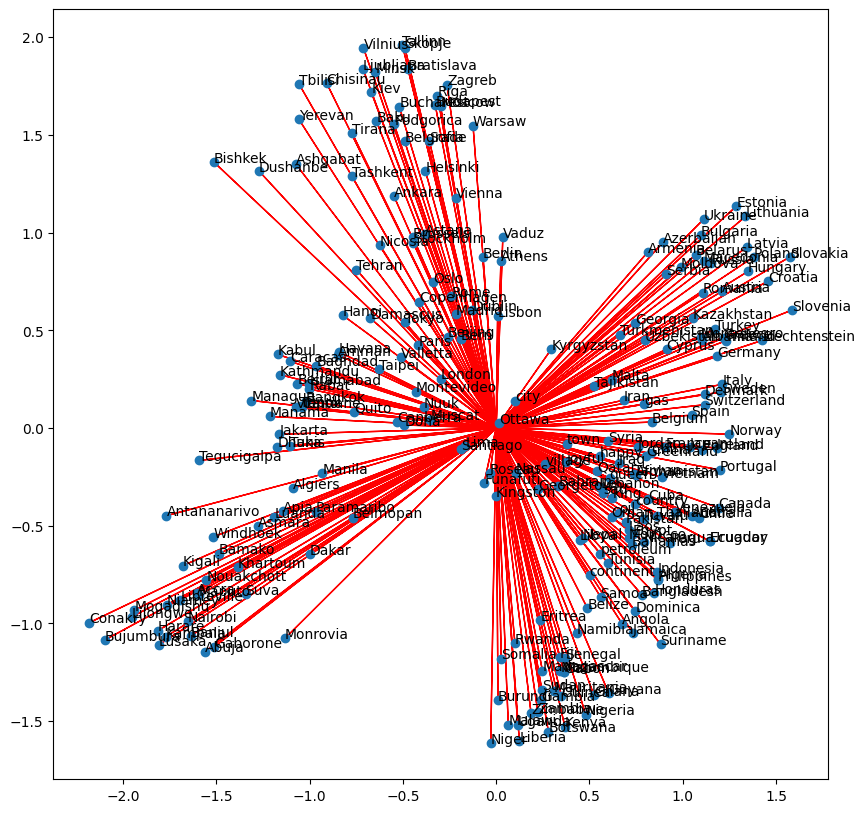

In [79]:
# Reduce to 2d and plot 
pca = PCA(n_components=3)
vectors_2d = pca.fit_transform(vectors)

words_list = list(df['word'])

fig, ax = plt.subplots(figsize = (10,10))

# plot lines
for w in vectors_2d:
    ax.arrow(0,0, w[0], w[1], head_width=0.005, head_length=0.005, fc='r', ec='r', width = 1e-5)
    
ax.scatter(vectors_2d[:, 0], vectors_2d[:,1]) # add points

for i in range(0, len(words_list)):
    ax.annotate(words_list[i], (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.show()